# 02 — EDA AV45

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

SEED = 1672891
random.seed(SEED)
np.random.seed(SEED)

In [2]:
BASE_DIR = r"D:\Universidad\TFG\OASIS"

PATHS = {
    "AV45": {
        "X": os.path.join(BASE_DIR, "X_av45_128x128x64.npy"),
        "y": os.path.join(BASE_DIR, "y_av45_128x128x64.npy"),
        "meta": os.path.join(BASE_DIR, "metadata_av45_128x128x64.csv"),
    }
}

In [ ]:
def cargar_dataset(tracer):
    X = np.load(PATHS[tracer]["X"])
    y = np.load(PATHS[tracer]["y"])
    meta = pd.read_csv(PATHS[tracer]["meta"])
    return X, y, meta

def quitar_canal(X):
    return X[:, 0] if X.ndim == 5 else X

X_av45, y_av45, meta_av45 = cargar_dataset("AV45")

AV45: (726, 128, 128, 64) [610 116]


,ruta_imagen,filename,OASISID,days_from_entry,tracer,label_binaria,CDRTOT_match,days_to_visit_match,days_diff_label
0,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30001_ses-d2430_acq-AV45_pet.nii.gz,OAS30001,2430,AV45,0,0.0,2181.0,249.0
1,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz,OAS30002,2340,AV45,0,0.0,2263.0,77.0
2,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30003_ses-d2682_acq-AV45_pet.nii.gz,OAS30003,2682,AV45,0,0.0,2630.0,52.0
3,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30003_ses-d3731_acq-AV45_pet.nii.gz,OAS30003,3731,AV45,0,0.0,3633.0,98.0
4,D:\Universidad\TFG\OASIS\av45\www.nitrc.org\ir...,sub-OAS30004_ses-d3457_acq-AV45_pet.nii.gz,OAS30004,3457,AV45,0,0.0,3458.0,1.0


## 1. Medias por grupo y mapas de diferencia

Estos mapas permiten ver si existe señal global entre grupos. No sustituyen al entrenamiento, pero ayudan a interpretar el problema.

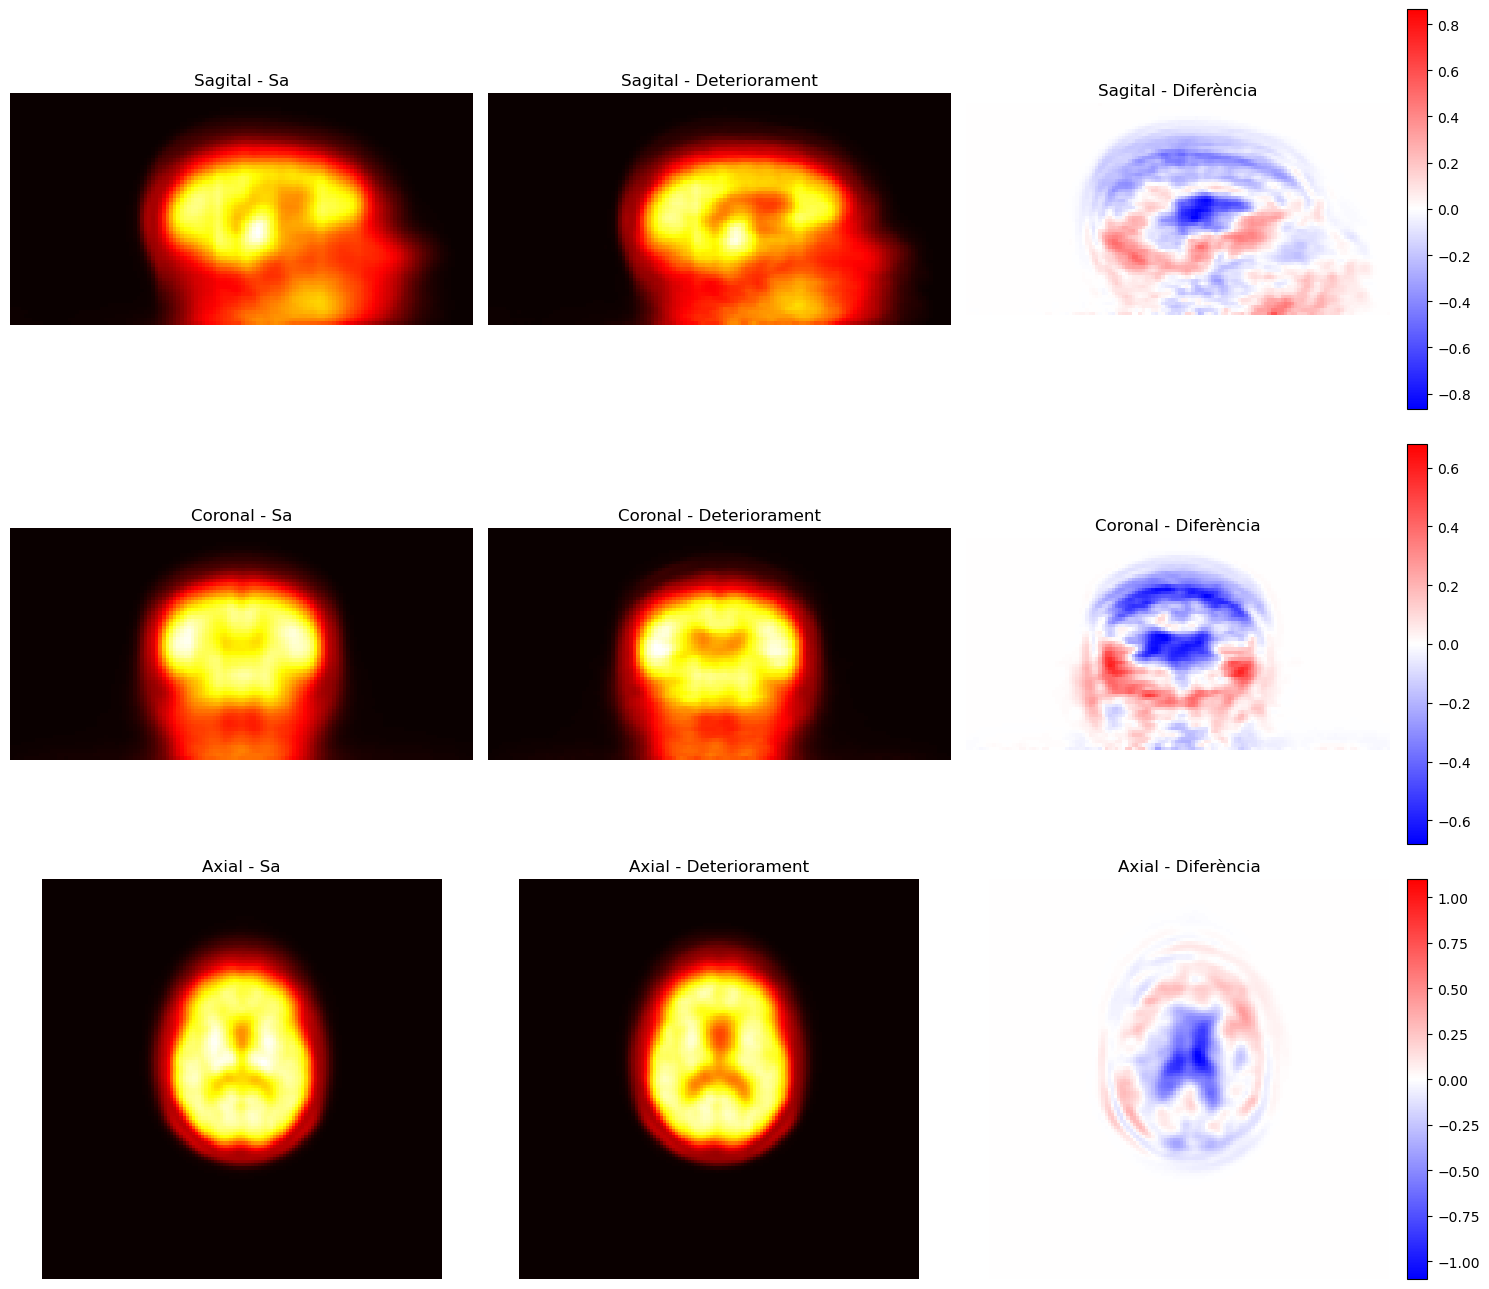

In [ ]:
def plot_medias_diferencia_3ejes(X, y, tracer="AV45"):
    Xv = quitar_canal(X).astype(np.float32)

    mean_sano = Xv[y == 0].mean(axis=0)
    mean_pos = Xv[y == 1].mean(axis=0)
    diff = mean_pos - mean_sano

    # Talls centrals dels tres eixos
    x_mid = Xv.shape[1] // 2  # sagital
    y_mid = Xv.shape[2] // 2  # coronal
    z_mid = Xv.shape[3] // 2  # axial

    cortes = {
        "Sagital": (
            mean_sano[x_mid, :, :],
            mean_pos[x_mid, :, :],
            diff[x_mid, :, :]
        ),
        "Coronal": (
            mean_sano[:, y_mid, :],
            mean_pos[:, y_mid, :],
            diff[:, y_mid, :]
        ),
        "Axial": (
            mean_sano[:, :, z_mid],
            mean_pos[:, :, z_mid],
            diff[:, :, z_mid]
        )
    }

    fig, axes = plt.subplots(3, 3, figsize=(15, 13))

    for fila, (plano, (s0, s1, sd)) in enumerate(cortes.items()):
        vmin = min(s0.min(), s1.min())
        vmax = max(s0.max(), s1.max())
        dabs = np.max(np.abs(sd))

        axes[fila, 0].imshow(np.rot90(s0), cmap="hot", vmin=vmin, vmax=vmax)
        axes[fila, 0].set_title(f"{plano} - Sa")
        axes[fila, 0].axis("off")

        axes[fila, 1].imshow(np.rot90(s1), cmap="hot", vmin=vmin, vmax=vmax)
        axes[fila, 1].set_title(f"{plano} - Deteriorament")
        axes[fila, 1].axis("off")

        im = axes[fila, 2].imshow(np.rot90(sd), cmap="bwr", vmin=-dabs, vmax=dabs)
        axes[fila, 2].set_title(f"{plano} - Diferència")
        axes[fila, 2].axis("off")

        plt.colorbar(im, ax=axes[fila, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


plot_medias_diferencia_3ejes(X_av45, y_av45, "AV45")

## 3. PCA, KMeans y t-SNE

Se reducen los volúmenes a `32x32x32` para que el análisis sea computacionalmente manejable.


AV45
NaN iniciales: 0
Inf iniciales: 0
AV45 — componentes PCA seleccionadas: 30
AV45 — varianza explicada acumulada: 0.9003


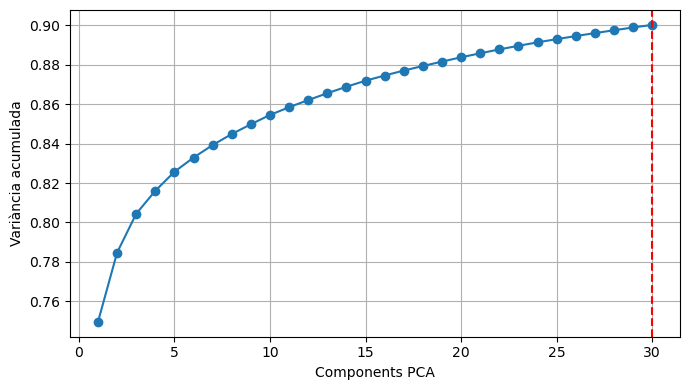

Clusters: [423 303]
ARI: 0.0013404463580084403
NMI: 0.00013048785709485216


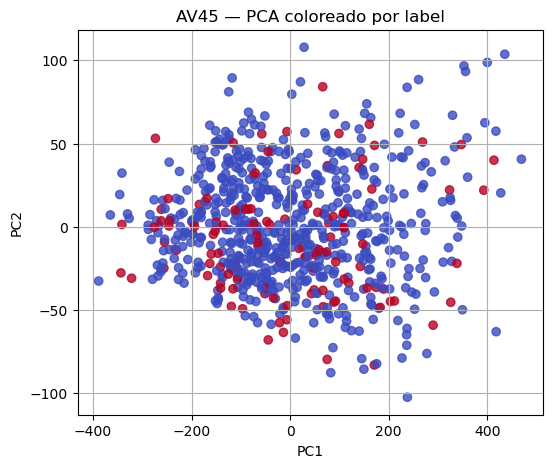

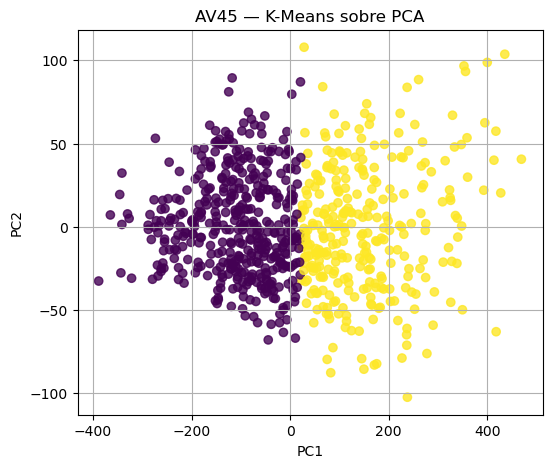

In [ ]:
def resize_volume(volume, target_shape=(32, 32, 32)):
    factors = [t / s for t, s in zip(target_shape, volume.shape)]
    return zoom(volume, factors, order=1).astype(np.float32)


def aplicar_pca_por_varianza(X_scaled, varianza_objetivo=0.90, seed=SEED):
    """
    Ajusta PCA seleccionant automàticament el número mínim de components
    necessari per explicar al menys varianza_objetivo.

    Exemple:
        varianza_objetivo=0.90 -> conserva components fins explicar >=90%.
    """
    if not (0 < varianza_objetivo <= 1):
        raise ValueError("varianza_objetivo debe estar entre 0 y 1.")

    pca = PCA(n_components=varianza_objetivo, svd_solver="full", random_state=seed)
    X_pca = pca.fit_transform(X_scaled)

    varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
    n_componentes = X_pca.shape[1]

    return pca, X_pca, n_componentes, varianza_acumulada


def run_pca_kmeans(X, y, tracer, varianza_objetivo=0.90, target_shape=(32, 32, 32)):
    Xv = quitar_canal(X).astype(np.float32)

    print(f"\n{tracer}")
    print("NaN iniciales:", np.isnan(Xv).sum())
    print("Inf iniciales:", np.isinf(Xv).sum())

    Xv = np.nan_to_num(Xv, nan=0.0, posinf=0.0, neginf=0.0)

    X_small = np.array(
        [resize_volume(vol, target_shape) for vol in Xv],
        dtype=np.float32
    )

    X_small = np.nan_to_num(X_small, nan=0.0, posinf=0.0, neginf=0.0)

    X_flat = X_small.reshape(X_small.shape[0], -1)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flat)
    X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=0.0, neginf=0.0)

    pca, X_pca, n_componentes, varianza_acumulada = aplicar_pca_por_varianza(
        X_scaled,
        varianza_objetivo=varianza_objetivo,
        seed=SEED
    )

    print(f"{tracer} — componentes PCA seleccionadas: {n_componentes}")
    print(f"{tracer} — varianza explicada acumulada: {varianza_acumulada[-1]:.4f}")

    # Gráfico de varianza acumulada
    plt.figure(figsize=(7, 4))
    plt.plot(np.arange(1, n_componentes + 1), varianza_acumulada, marker="o")
    plt.axvline(n_componentes, linestyle="--", color="red")
    plt.xlabel("Components PCA")
    plt.ylabel("Variància acumulada")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=20)
    clusters = kmeans.fit_predict(X_pca)

    print("Clusters:", np.bincount(clusters))
    print("ARI:", adjusted_rand_score(y, clusters))
    print("NMI:", normalized_mutual_info_score(y, clusters))

    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    plt.title(f"{tracer} — PCA coloreado por label")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    # K-Means sobre PCA
    plt.figure(figsize=(6, 5))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", alpha=0.8)
    plt.title(f"{tracer} — K-Means sobre PCA")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    return {
        "pca": pca,
        "X_pca": X_pca,
        "n_componentes": n_componentes,
        "varianza_acumulada": varianza_acumulada,
        "clusters": clusters
    }


res_av45 = run_pca_kmeans(
    X_av45,
    y_av45,
    "AV45",
    varianza_objetivo=0.90
)

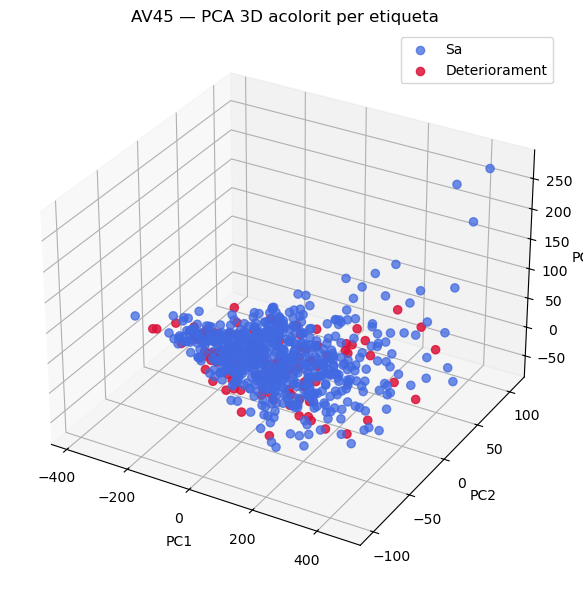

In [7]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_3d(X_pca, y, tracer="AV45"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    y = np.asarray(y)

    ax.scatter(
        X_pca[y == 0, 0],
        X_pca[y == 0, 1],
        X_pca[y == 0, 2],
        color="royalblue",
        alpha=0.75,
        s=35,
        label="Sa"
    )

    ax.scatter(
        X_pca[y == 1, 0],
        X_pca[y == 1, 1],
        X_pca[y == 1, 2],
        color="crimson",
        alpha=0.85,
        s=35,
        label="Deteriorament"
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    ax.set_title(f"{tracer} — PCA 3D acolorit per etiqueta")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_pca_3d(res_av45["X_pca"], y_av45, "AV45")

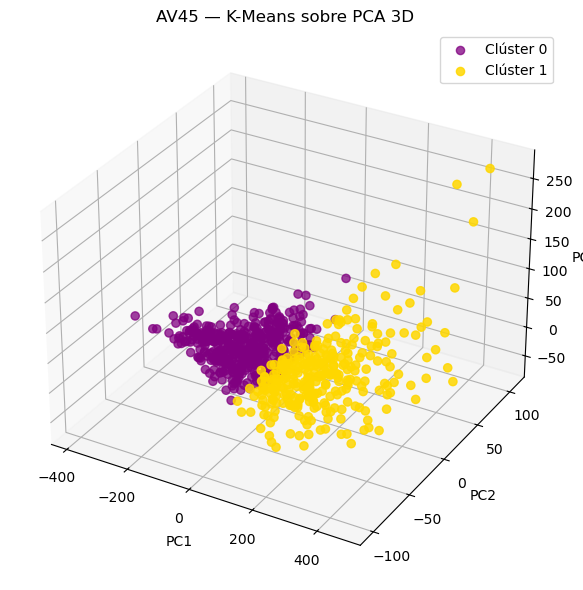

In [8]:
def plot_kmeans_3d(X_pca, clusters, tracer="AV45"):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    clusters = np.asarray(clusters)

    ax.scatter(
        X_pca[clusters == 0, 0],
        X_pca[clusters == 0, 1],
        X_pca[clusters == 0, 2],
        color="purple",
        alpha=0.75,
        s=35,
        label="Clúster 0"
    )

    ax.scatter(
        X_pca[clusters == 1, 0],
        X_pca[clusters == 1, 1],
        X_pca[clusters == 1, 2],
        color="gold",
        alpha=0.85,
        s=35,
        label="Clúster 1"
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")

    ax.set_title(f"{tracer} — K-Means sobre PCA 3D")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_kmeans_3d(res_av45["X_pca"], res_av45["clusters"], "AV45")